In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- System matrices (SI units) ---
M = np.array([[215.0, -20.0],
              [-20.0, 150.0]], dtype=float)

C = np.array([[2000.0,    0.0],
              [   0.0, 1000.0]], dtype=float)

K = np.array([[4.21e6,   0.0],
              [  0.0, 4.61e6]], dtype=float)

def load_macro_from_npz(npz_path, axes=(0, 1)):
    data = np.load(npz_path, allow_pickle=False)

    Lambda = data["Lambda_xyz"]  # (3,3)
    Dx     = data["Dx_xyz"]      # (3,3)
    Kx     = data["Kx_xyz"]      # (3,3)

    a0, a1 = axes

    M2 = Lambda[np.ix_([a0, a1], [a0, a1])]
    C2 = Dx[np.ix_([a0, a1], [a0, a1])]
    K2 = Kx[np.ix_([a0, a1], [a0, a1])]

    extras = {k: data[k] for k in data.files if k not in ["Lambda_xyz", "Dx_xyz", "Kx_xyz"]}
    return M2, C2, K2, extras

M2, C2, K2, extras = load_macro_from_npz("./data/linearized_operational_space_xyz.npz", axes=(0, 1))  # (x,y)
M = M2
C = C2
K = K2


# --- Attached mass (not used in G(s) yet) ---
M_micro = np.diag([100.0, 100.0])  # kg

Z = np.zeros((2,2))
I = np.eye(2)
Minv = np.linalg.inv(M + M_micro)

A = np.block([
    [Z, I],
    [-Minv @ K, -Minv @ C]
])

eigvals = np.linalg.eigvals(A)


In [3]:
def build_second_order_ss(M, C, K):
    """
    Convert: M xdd + C xd + K x = 0  (n=2)  to
    z = [x; xd] in R^4,   zdot = A z
    """
    I = np.eye(2)
    Z = np.zeros((2,2))
    Minv = np.linalg.inv(M)

    A = np.block([
        [Z, I],
        [-Minv @ K, -Minv @ C]
    ])
    return A


# ============================================================
# 1) Rigidly attached point mass (fixed offset p0; pure translation)
# ============================================================

def build_attached_mass_model(M, C, K, M_micro):
    M_tot = M + M_micro
    A = build_second_order_ss(M_tot, C, K)
    return A, M_tot


# ============================================================
# 2) Absolute-coordinate actuator model (two-body) WITHOUT process force
# ============================================================

def build_absolute_actuated_model(M, C, K, M_micro, nu):
    I = np.eye(2)

    Minv = np.linalg.inv(M)
    Mmic_inv = np.linalg.inv(M_micro)

    Bv = nu * np.eye(2)

    A = np.zeros((8,8))
    Bu = np.zeros((8,2))

    # kinematics
    A[0:2, 4:6] = I          # xdot = v
    A[2:4, 6:8] = I          # xhatdot = vhat

    # structure: vdot = M^-1(-Kx - Cv + Bv(vhat-v) + u)
    A[4:6, 0:2] = -Minv @ K
    A[4:6, 4:6] = -Minv @ (C + Bv)
    A[4:6, 6:8] =  Minv @ Bv
    Bu[4:6, :]  =  Minv

    # micro: vhatdot = Mmic^-1(-Bv(vhat-v) - u)
    A[6:8, 4:6] =  Mmic_inv @ Bv
    A[6:8, 6:8] = -Mmic_inv @ Bv
    Bu[6:8, :]  = -Mmic_inv

    return A, Bu


# ============================================================
# 3) Absolute-coordinate plant WITH process force absorbed into A
# ============================================================

def build_absolute_model_wProcess(M, C, K, M_micro, nu, Kp=None):
    A_nom, Bu = build_absolute_actuated_model(M, C, K, M_micro, nu) # We add the process stiffness to the model
    G_a = np.zeros((8, 2))
    G_a [6:8, :] = np.linalg.inv(M_micro)
    H = np.zeros((2, 8))
    H[:, 2:4] = np.eye(2)

    if Kp is None:
        A_proc = A_nom
    else:
        Kp = np.asarray(Kp, dtype=float)
        A_proc = A_nom + G_a @ (+Kp) @ H 

    return A_proc, Bu, G_a, H, A_nom

from scipy.linalg import solve_continuous_are
def lqr(A, B, Q, R):
    """Continuous-time LQR: u = -K z"""
    P = solve_continuous_are(A, B, Q, R)
    K = np.linalg.solve(R, B.T @ P)
    return K, P


from scipy.linalg import solve_continuous_are

def lqi(
    A, B, # Introduce system matrices
    Qx, Qi, R, # Introduce LQR cost matrices for state, integrator, and input
    S, # Selection matrix for integrator states 
    
    ):
    
    n = A.shape[0]
    m = B.shape[1]
     
    S = np.asarray(S)
    pI = S.shape[0]

        
    
    A_aug = np.block([
        [ A,            np.zeros((n, pI))],
        [-S,            np.zeros((pI, pI))]
    ])
    
    B_aug = np.vstack([
        B,
        np.zeros((pI, m))
    ])
    
    Q_aug = np.block([
        [Qx,                 np.zeros((n, pI))],
        [np.zeros((pI, n)),  Qi]
    ])

    # Solve CARE and compute gain
    P = solve_continuous_are(A_aug, B_aug, Q_aug, R)
    K = np.linalg.solve(R, B_aug.T @ P)
    
    return  K, A_aug, B_aug




In [16]:
# Build system matrices
# state = [x; xhat] in R^8,   input = u in R^2
A_sys, B_sys = build_absolute_actuated_model(M, C, K, M_micro, nu=1e4) # Full system matrices
C_sys = np.eye(8)  # We can measure all states for LQR; for LQI we will track xhat to zero

# LQR Feedback Gain

# Cost function matrices
# Q_lqr = np.eye(8)*1e4  # State penalty (tune)
# R_lqr = np.eye(2)     # Input penalty (tune)

Q_axis = np.diag([1e0, 1e8, 1e0, 1e6])
Q_lqr = np.block([[Q_axis, np.zeros((4,4))],
              [np.zeros((4,4)), Q_axis]])
R_lqr = np.eye(2)*1e-4

K_lqr, _ = lqr(A_sys, B_sys, Q=Q_lqr, R=R_lqr)  # LQR gain for full state feedback

# LQI Feedback Gain including augmented system
# Augmented state = [x; xhat; integral of (xhat - 0)] in R^10

# Augmented Costs for integral state 

n_integal_state = 2
Qi = np.eye(n_integal_state)*1e2  # Integral state penalty (tune)

S = np.zeros((n_integal_state, A_sys.shape[0])) 
S[:, 2:4] = np.eye(2) # We track x_hat to zero

K_lqi, A_aug, B_aug = lqi(
    A_sys, B_sys,
    Qx=Q_lqr, Qi=Qi, R=R_lqr,
    S=S
)

A_cl = A_sys - B_sys @ K_lqr
A_cl_int = A_aug - B_aug @ K_lqi
C_cl_int = np.block([C_sys, np.zeros((C_sys.shape[0], n_integal_state))])  # We only care about the original states for output

A = A_sys
Bu = B_sys

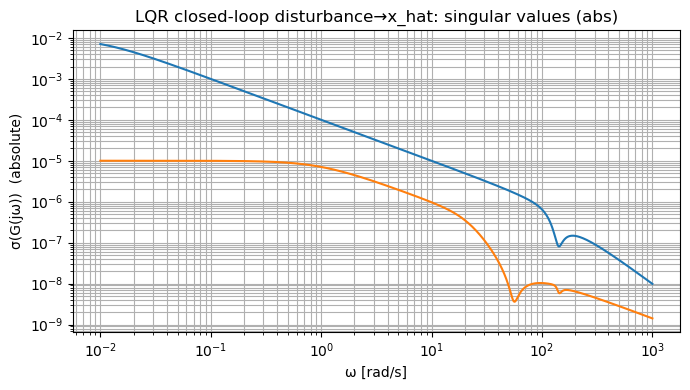

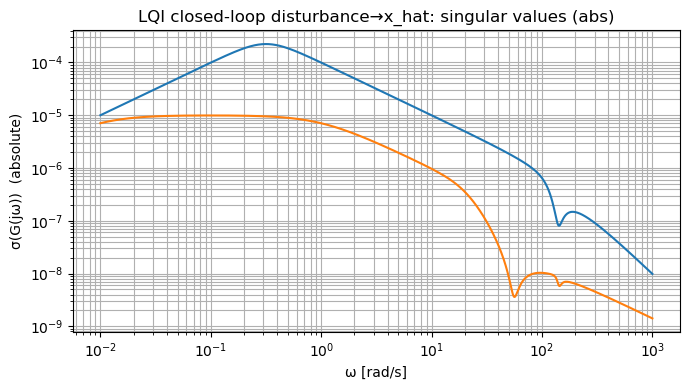

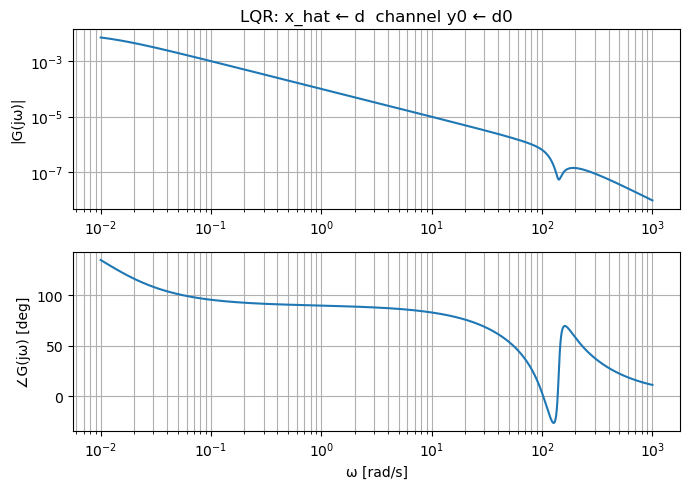

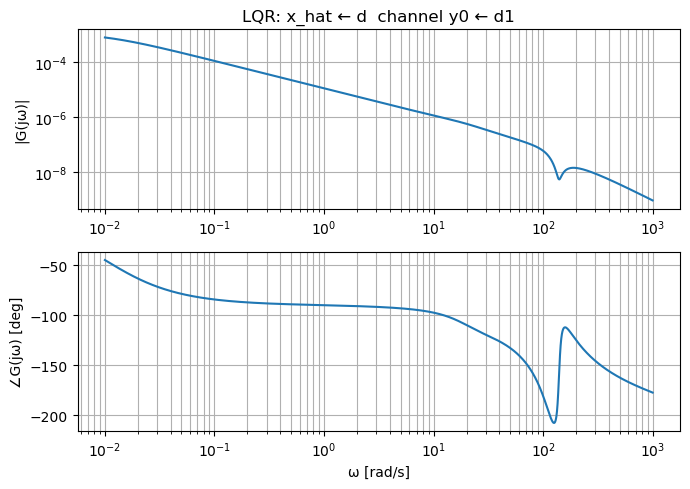

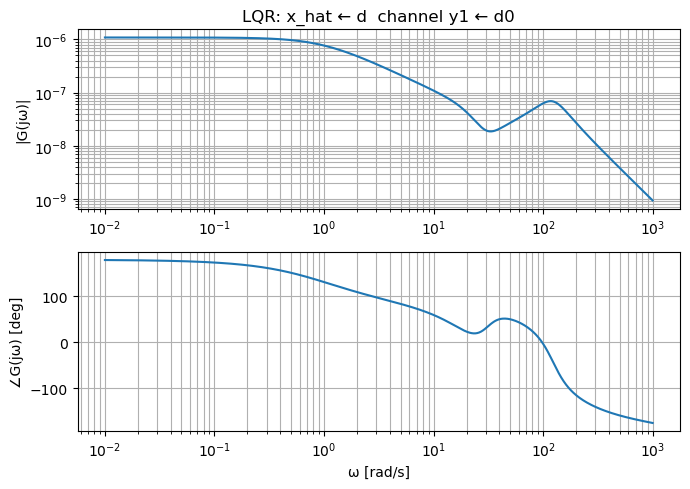

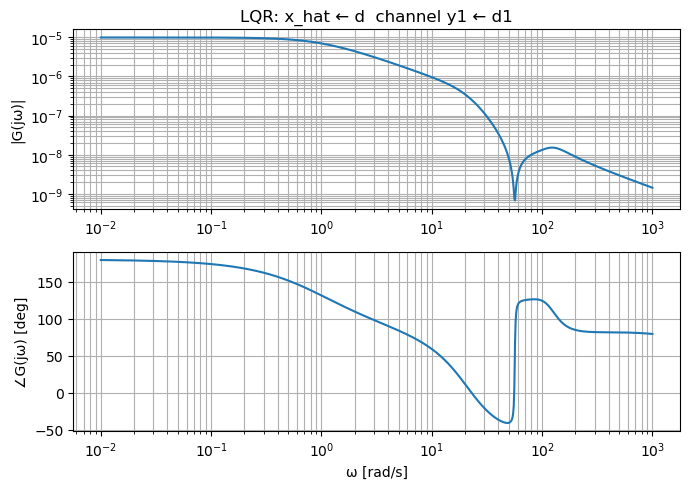

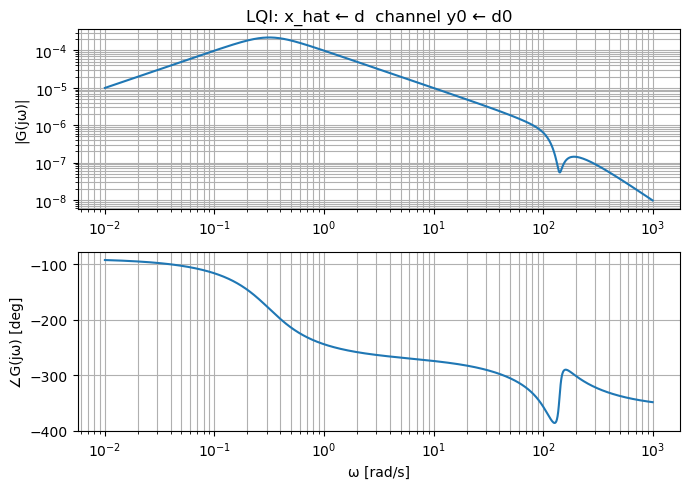

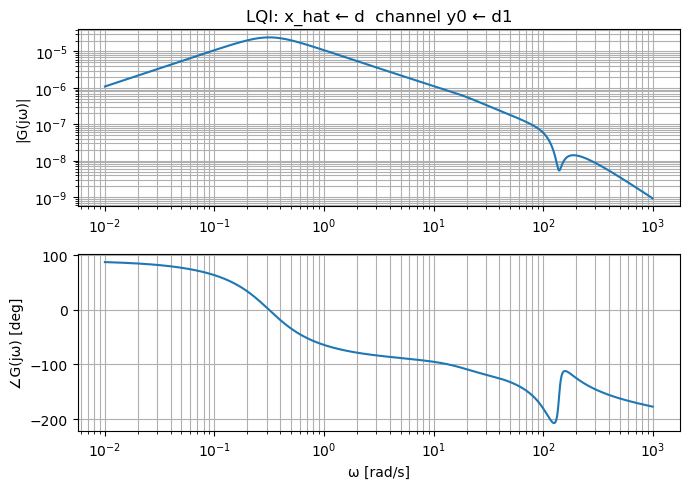

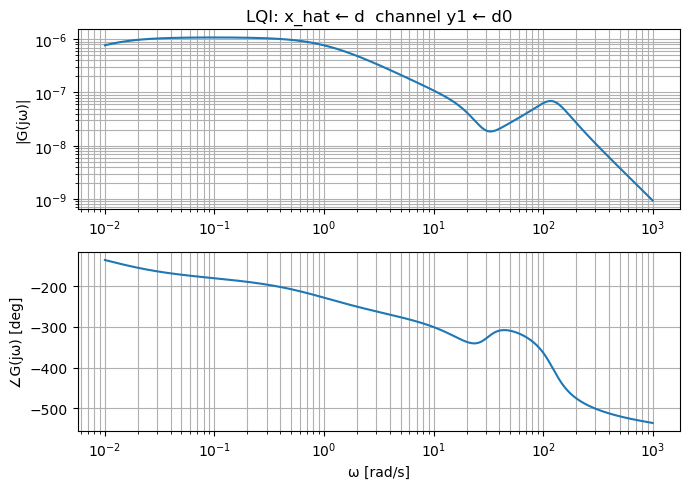

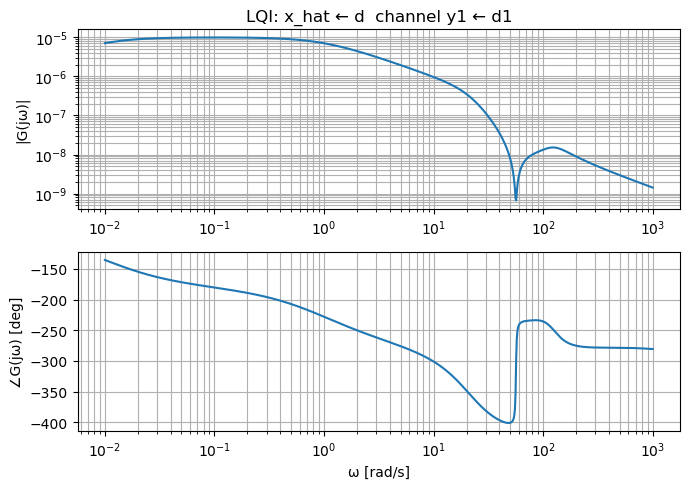

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def freqresp_mimo(A, B, C, D=None, w=None):
    """
    H(jw) = C (jwI - A)^(-1) B + D
    Returns:
      w: (N,) rad/s
      H: (N, p, m) complex
    """
    A = np.asarray(A); B = np.asarray(B); C = np.asarray(C)
    n = A.shape[0]
    p = C.shape[0]
    m = B.shape[1]
    if D is None:
        D = np.zeros((p, m))
    D = np.asarray(D)

    if w is None:
        w = np.logspace(-2, 3, 800)  # rad/s

    H = np.empty((len(w), p, m), dtype=complex)
    I = np.eye(n)

    for k, wk in enumerate(w):
        X = np.linalg.solve(1j * wk * I - A, B)  # (n,m)
        H[k] = C @ X + D                          # (p,m)
    return w, H

def bode_mimo_channels(w, H, title_prefix=""):
    """
    Plot magnitude (absolute) + phase for each element H_ij.
    """
    _, p, m = H.shape
    for i in range(p):
        for j in range(m):
            hij = H[:, i, j]
            mag = np.abs(hij)  # ABS magnitude (not dB)
            phase = np.unwrap(np.angle(hij)) * 180/np.pi

            fig = plt.figure(figsize=(7, 5))
            ax1 = fig.add_subplot(2, 1, 1)
            ax1.loglog(w, np.maximum(mag, 1e-16))
            ax1.set_ylabel("|G(jω)|")
            ax1.grid(True, which="both")
            ax1.set_title(f"{title_prefix}  channel y{i} ← d{j}")

            ax2 = fig.add_subplot(2, 1, 2)
            ax2.semilogx(w, phase)
            ax2.set_ylabel("∠G(jω) [deg]")
            ax2.set_xlabel("ω [rad/s]")
            ax2.grid(True, which="both")
            plt.tight_layout()

def bode_singular_values(w, H, title=""):
    """
    Plot singular values of H(jw) (absolute, not dB).
    Good summary for MIMO disturbance rejection.
    """
    sigmas = []
    for k in range(len(w)):
        s = np.linalg.svd(H[k], compute_uv=False)  # singular values
        sigmas.append(s)
    sigmas = np.array(sigmas)  # (N, min(p,m))

    plt.figure(figsize=(7, 4))
    for r in range(sigmas.shape[1]):
        plt.loglog(w, np.maximum(sigmas[:, r], 1e-16))
    plt.title(title)
    plt.xlabel("ω [rad/s]")
    plt.ylabel("σ(G(jω))  (absolute)")
    plt.grid(True, which="both")
    plt.tight_layout()


# -----------------------------
# Choose disturbance-to-output map
# d enters additively through the same channels as u (via B)
# output y = x_hat states (2:4)
# -----------------------------

n = A_sys.shape[0]  # should be 8
m = B_sys.shape[1]  # should be 2

# Output: x_hat (states 2 and 3)
C_y = np.zeros((2, n))
C_y[0, 2] = 1.0
C_y[1, 3] = 1.0

# LQR closed-loop (disturbance d through B_sys)
A_cl = A_sys - B_sys @ K_lqr
B_d_lqr = B_sys
D_lqr = np.zeros((2, m))

# LQI closed-loop (augmented)
A_cl_int = A_aug - B_aug @ K_lqi
pI = A_aug.shape[0] - n  # integrator dimension (should be 2)

C_y_aug = np.hstack([C_y, np.zeros((2, pI))])  # y depends only on original states
B_d_lqi = B_aug
D_lqi = np.zeros((2, m))

# Frequency grid
w = np.logspace(-2, 3, 900)

# Compute freq responses d -> y
w, H_lqr = freqresp_mimo(A_cl,     B_d_lqr, C_y,     D_lqr, w=w)
w, H_lqi = freqresp_mimo(A_cl_int, B_d_lqi, C_y_aug, D_lqi, w=w)

# Plot singular-value Bodes (nice MIMO summary)
bode_singular_values(w, H_lqr, title="LQR closed-loop disturbance→x_hat: singular values (abs)")
bode_singular_values(w, H_lqi, title="LQI closed-loop disturbance→x_hat: singular values (abs)")

# Plot per-channel Bode magnitude/phase (2 outputs x 2 inputs = 4 plots each)
bode_mimo_channels(w, H_lqr, title_prefix="LQR: x_hat ← d")
bode_mimo_channels(w, H_lqi, title_prefix="LQI: x_hat ← d")

plt.show()

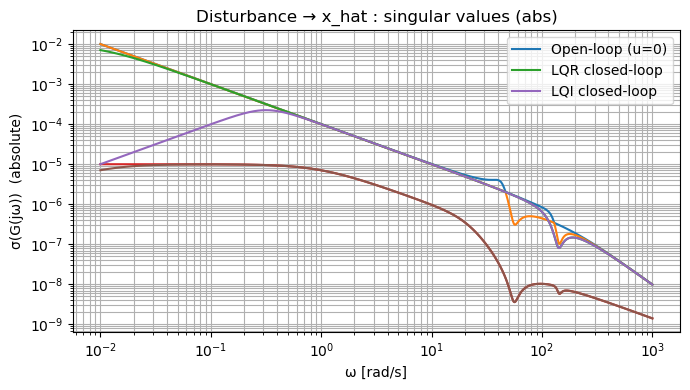

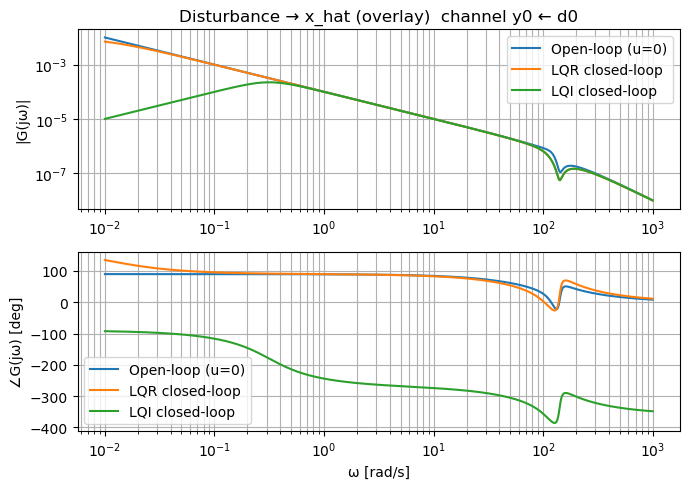

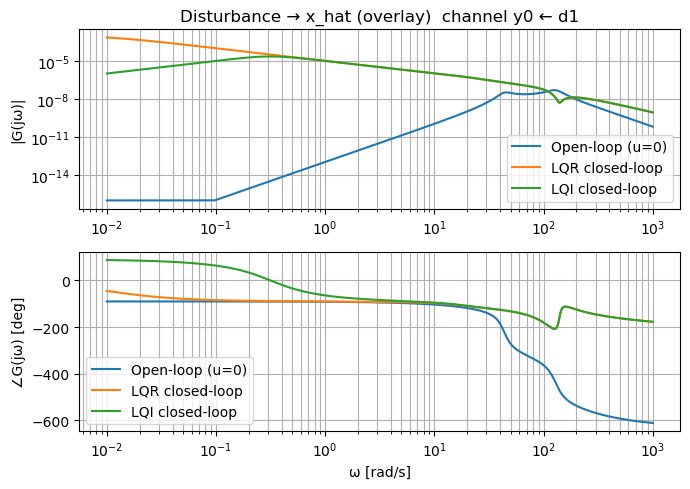

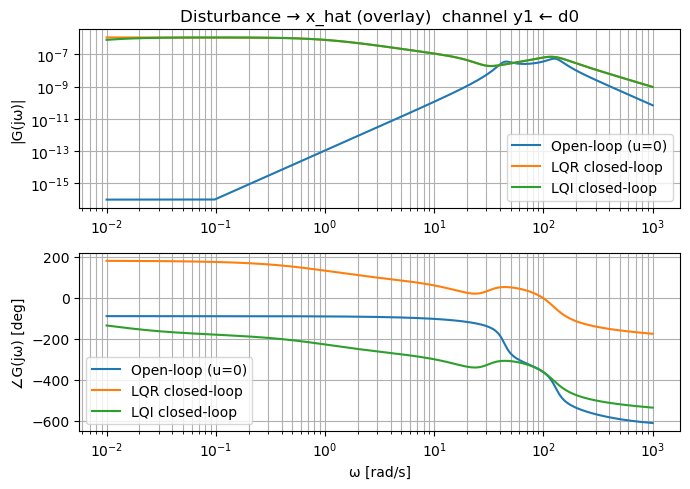

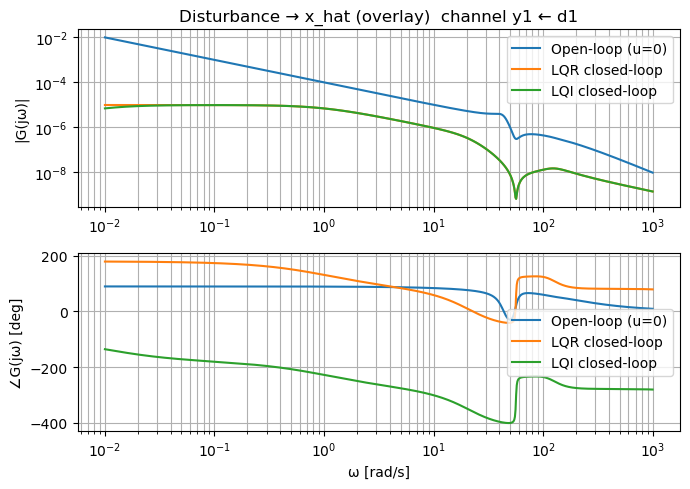

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def freqresp_mimo(A, B, C, D=None, w=None):
    A = np.asarray(A); B = np.asarray(B); C = np.asarray(C)
    n = A.shape[0]
    p = C.shape[0]
    m = B.shape[1]
    if D is None:
        D = np.zeros((p, m))
    D = np.asarray(D)

    if w is None:
        w = np.logspace(-2, 3, 800)  # rad/s

    H = np.empty((len(w), p, m), dtype=complex)
    I = np.eye(n)

    for k, wk in enumerate(w):
        X = np.linalg.solve(1j * wk * I - A, B)  # (n,m)
        H[k] = C @ X + D                         # (p,m)
    return w, H

def bode_mimo_channels_overlay(w, H_list, labels, title_prefix=""):
    """
    Overlay magnitude+phase for each channel for multiple systems.
    H_list: list of H arrays, each (N,p,m)
    """
    p = H_list[0].shape[1]
    m = H_list[0].shape[2]

    for i in range(p):
        for j in range(m):
            fig = plt.figure(figsize=(7, 5))
            ax1 = fig.add_subplot(2, 1, 1)
            ax2 = fig.add_subplot(2, 1, 2)

            for H, lab in zip(H_list, labels):
                hij = H[:, i, j]
                mag = np.abs(hij)
                phase = np.unwrap(np.angle(hij)) * 180/np.pi
                ax1.loglog(w, np.maximum(mag, 1e-16), label=lab)
                ax2.semilogx(w, phase, label=lab)

            ax1.set_ylabel("|G(jω)|")
            ax1.grid(True, which="both")
            ax1.set_title(f"{title_prefix}  channel y{i} ← d{j}")
            ax1.legend()

            ax2.set_ylabel("∠G(jω) [deg]")
            ax2.set_xlabel("ω [rad/s]")
            ax2.grid(True, which="both")
            ax2.legend()

            plt.tight_layout()

def bode_singular_values_overlay(w, H_list, labels, title=""):
    """
    Overlay singular values for multiple MIMO systems.
    """
    plt.figure(figsize=(7, 4))
    for H, lab in zip(H_list, labels):
        sigmas = []
        for k in range(len(w)):
            s = np.linalg.svd(H[k], compute_uv=False)
            sigmas.append(s)
        sigmas = np.array(sigmas)  # (N, min(p,m))

        # plot all singular value branches for this system
        for r in range(sigmas.shape[1]):
            # label only first branch to keep legend clean
            if r == 0:
                plt.loglog(w, np.maximum(sigmas[:, r], 1e-16), label=lab)
            else:
                plt.loglog(w, np.maximum(sigmas[:, r], 1e-16))

    plt.title(title)
    plt.xlabel("ω [rad/s]")
    plt.ylabel("σ(G(jω))  (absolute)")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()


# -----------------------------
# Output: x_hat states (2:4) -> you chose states 2 and 3
# -----------------------------
n = A_sys.shape[0]  # 8
m = B_sys.shape[1]  # 2

C_y = np.zeros((2, n))
C_y[0, 2] = 1.0
C_y[1, 3] = 1.0

# Frequency grid
w = np.logspace(-2, 3, 900)

# -----------------------------
# 0) OPEN LOOP baseline
# Option A (robust / consistent): open-loop = A_sys with u=0
# -----------------------------
A_ol = A_sys
B_d_ol = B_sys
D_ol = np.zeros((2, m))

w, H_ol = freqresp_mimo(A_ol, B_d_ol, C_y, D_ol, w=w)

# If you *really* want A from build_attached_mass_model(), do:
# A_ol, M_tot = build_attached_mass_model(M, C, K, M_micro)
# and then you MUST supply a compatible B_d_ol for that model.


# -----------------------------
# 1) LQR closed-loop baseline: x' = (A - BK)x + B d
# -----------------------------
A_cl = A_sys - B_sys @ K_lqr
B_d_lqr = B_sys
D_lqr = np.zeros((2, m))

w, H_lqr = freqresp_mimo(A_cl, B_d_lqr, C_y, D_lqr, w=w)

# -----------------------------
# 2) LQI closed-loop (augmented): x_a' = A_cl_int x_a + [B;0] d
# IMPORTANT: disturbance should NOT drive integrator states directly.
# So B_d_lqi should be [B_sys; 0], not B_aug.
# -----------------------------
A_cl_int = A_aug - B_aug @ K_lqi
pI = A_aug.shape[0] - n  # integrator dimension (2)

C_y_aug = np.hstack([C_y, np.zeros((2, pI))])

B_d_lqi = np.vstack([B_sys, np.zeros((pI, m))])
D_lqi = np.zeros((2, m))

w, H_lqi = freqresp_mimo(A_cl_int, B_d_lqi, C_y_aug, D_lqi, w=w)


# -----------------------------
# Overlay plots
# -----------------------------
labels = ["Open-loop (u=0)", "LQR closed-loop", "LQI closed-loop"]

bode_singular_values_overlay(
    w,
    [H_ol, H_lqr, H_lqi],
    labels,
    title="Disturbance → x_hat : singular values (abs)"
)

bode_mimo_channels_overlay(
    w,
    [H_ol, H_lqr, H_lqi],
    labels,
    title_prefix="Disturbance → x_hat (overlay)"
)

plt.show()